# 01 - CNN Baseline (ResNet18)

J'entraîne un ResNet18 sur le dataset Mendeley BT-MRI nettoyé (4 classes). Ce modèle sert de référence déterministe pour comparer aux modèles bayésiens.

### 1. Imports et seed

In [1]:
import os, random, re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             balanced_accuracy_score, classification_report)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


### 2. Chemins et hyperparamètres

In [2]:
DATAROOT    = "/Users/teodul/Documents/Memoire/Brain Tumor MRI clean"
TRAIN_DIR   = os.path.join(DATAROOT, "Train")
TEST_DIR    = os.path.join(DATAROOT, "Test")
SAVE_DIR    = "runs_cnn_baseline"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 1e-4
NUM_WORKERS = 0
PATIENCE    = 3

### 3. Transforms

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

### 4. Datasets et loaders

In [4]:
from torch.utils.data import Subset

train_full_aug = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
train_full_val = datasets.ImageFolder(TRAIN_DIR, transform=val_tf)
test_ds        = datasets.ImageFolder(TEST_DIR,  transform=val_tf)

# Split train/val stratifié par classe (85 % / 15 %), aléatoire
train_idx, val_idx = [], []
rng = np.random.default_rng(SEED)

for class_name, class_idx in train_full_aug.class_to_idx.items():
    cls_indices = [i for i, (_, y) in enumerate(train_full_aug.samples) if y == class_idx]
    cls_indices = list(rng.permutation(cls_indices))
    n_val = max(1, int(0.15 * len(cls_indices)))
    val_idx   += cls_indices[:n_val]
    train_idx += cls_indices[n_val:]

train_ds = Subset(train_full_aug, train_idx)
val_ds   = Subset(train_full_val, val_idx)

print("Classes:", train_full_aug.classes)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

labels        = [train_full_aug.targets[i] for i in train_idx]
counts        = np.bincount(labels)
print("Counts train:", dict(zip(train_full_aug.classes, counts)))

class_weights  = 1.0 / counts
sample_weights = class_weights[labels]
g_gen = torch.Generator(); g_gen.manual_seed(SEED)
sampler = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, generator=g_gen)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 3917 | Val: 689 | Test: 1149
Counts train: {'glioma': 1434, 'meningioma': 976, 'notumor': 504, 'pituitary': 1003}


### 5. Modèle ResNet18

In [5]:
NUM_CLASSES = 4

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Params entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Params entraînables : 11,308,868


### 6. Fonction d'évaluation

In [6]:
@torch.no_grad()
def evaluate(loader, model, split="Test"):
    model.eval()
    all_y, all_preds, all_probs = [], [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_y.extend(y.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

    all_y     = np.array(all_y)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    bal_acc = balanced_accuracy_score(all_y, all_preds)
    auc     = roc_auc_score(all_y, all_probs, multi_class="ovr", average="macro")
    cm      = confusion_matrix(all_y, all_preds)

    ds = loader.dataset
    classes = ds.classes if hasattr(ds, "classes") else ds.dataset.classes

    print(f"\n[{split}] bal_acc={bal_acc:.3f}  AUC={auc:.3f}")
    print("Confusion matrix:\n", cm)
    print(classification_report(all_y, all_preds,
                                 target_names=classes, digits=3))
    return bal_acc, auc

### 7. Entraînement et early stopping

In [7]:
history    = {"loss": [], "val_bal_acc": [], "val_auc": []}
best_auc   = -1.0
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    scheduler.step()
    print(f"\nepoch {epoch:02d}/{EPOCHS}  loss={np.mean(losses):.4f}")
    bal_acc, auc = evaluate(val_loader, model, split="Val")

    history["loss"].append(np.mean(losses))
    history["val_bal_acc"].append(bal_acc)
    history["val_auc"].append(auc)

    if auc > best_auc:
        best_auc   = auc
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "auc": auc,
            "bal_acc": bal_acc,
            "model_state": model.state_dict(),
            "classes": train_full_aug.classes,
            "img_size": IMG_SIZE,
        }, f"{SAVE_DIR}/best_final.pt")
        print(f"  ✓ saved (AUC val={auc:.3f})")
    else:
        no_improve += 1
        print(f"  patience {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print(f"Early stopping à l'epoch {epoch}")
            break

print(f"\nMeilleur AUC val : {best_auc:.3f}")
print(f"Modèle sauvegardé : {SAVE_DIR}/best_final.pt")


epoch 01/10  loss=0.4861

[Val] bal_acc=0.930  AUC=0.988
Confusion matrix:
 [[227  17   7   2]
 [  5 155   4   8]
 [  0   3  84   1]
 [  0   5   1 170]]
              precision    recall  f1-score   support

      glioma      0.978     0.897     0.936       253
  meningioma      0.861     0.901     0.881       172
     notumor      0.875     0.955     0.913        88
   pituitary      0.939     0.966     0.952       176

    accuracy                          0.923       689
   macro avg      0.913     0.930     0.921       689
weighted avg      0.926     0.923     0.923       689

  ✓ saved (AUC val=0.988)

epoch 02/10  loss=0.1893

[Val] bal_acc=0.936  AUC=0.991
Confusion matrix:
 [[233  11   5   4]
 [  2 154   2  14]
 [  3   0  83   2]
 [  1   0   2 173]]
              precision    recall  f1-score   support

      glioma      0.975     0.921     0.947       253
  meningioma      0.933     0.895     0.914       172
     notumor      0.902     0.943     0.922        88
   pituitary  

### 8. Évaluation sur le test set

In [8]:
ckpt = torch.load(f"{SAVE_DIR}/best_final.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Meilleur modèle chargé : epoch {ckpt['epoch']}, AUC val={ckpt['auc']:.3f}")
print("\n--- Évaluation finale sur le test set ---")
evaluate(test_loader, model, split="Test")

Meilleur modèle chargé : epoch 8, AUC val=0.998

--- Évaluation finale sur le test set ---

[Test] bal_acc=0.966  AUC=0.998
Confusion matrix:
 [[413   4   3   1]
 [  7 272   5   2]
 [  1   3 142   1]
 [  1   4   5 285]]
              precision    recall  f1-score   support

      glioma      0.979     0.981     0.980       421
  meningioma      0.961     0.951     0.956       286
     notumor      0.916     0.966     0.940       147
   pituitary      0.986     0.966     0.976       295

    accuracy                          0.968      1149
   macro avg      0.961     0.966     0.963      1149
weighted avg      0.968     0.968     0.968      1149



(0.9660336663062792, 0.9981826530475539)

### 9. Courbes

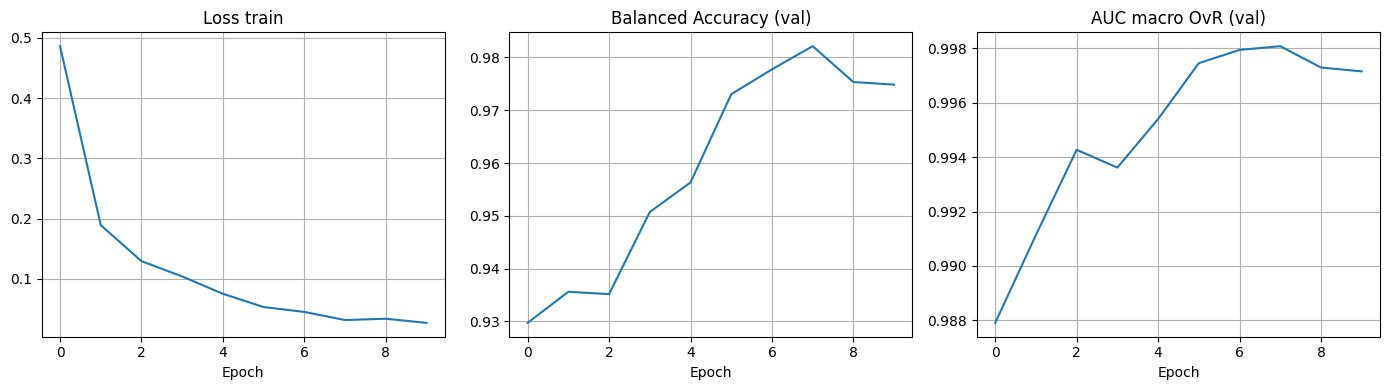

Figures sauvegardées dans runs_cnn_baseline


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history["loss"]);        axes[0].set_title("Loss train")
axes[1].plot(history["val_bal_acc"]); axes[1].set_title("Balanced Accuracy (val)")
axes[2].plot(history["val_auc"]);     axes[2].set_title("AUC macro OvR (val)")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/curves.png", dpi=150)
plt.show()
print("Figures sauvegardées dans", SAVE_DIR)